In [1]:
import numpy as np
from process_foil_data import solve_flux_spectrum, build_response_matrix_from_processed_data
import matplotlib.pyplot as plt

/home/cdunn314/libra/ngen_characterization_v2/neutronics


In [2]:
response_matrix, responses, response_errs = build_response_matrix_from_processed_data(angle=90)

responses = np.asarray(responses)
response_errs = np.asarray(response_errs)

# Detect fully-zero rows (within tol) and duplicate rows, remove them and corresponding entries
tol = 1e-30
row_norms = np.linalg.norm(response_matrix, axis=1)
zero_rows = np.where(row_norms <= tol)[0].tolist()

# find duplicate rows (keep first occurrence)
dup_rows = []
for i in range(response_matrix.shape[0]):
    if i in zero_rows or i in dup_rows:
        continue
    for j in range(i + 1, response_matrix.shape[0]):
        if j in zero_rows or j in dup_rows:
            continue
        if np.allclose(response_matrix[i], response_matrix[j], rtol=1e-6, atol=tol):
            dup_rows.append(j)

remove_rows = sorted(set(zero_rows + dup_rows))
if remove_rows:
    print(f"Removing redundant response rows: {remove_rows}")
    keep_mask = np.ones(response_matrix.shape[0], dtype=bool)
    keep_mask[remove_rows] = False
    response_matrix = response_matrix[keep_mask, :]
    responses = responses[keep_mask]
    response_errs = response_errs[keep_mask]

print("Responses:", responses)
print("Response Errors:", response_errs)

# Pretty-print response matrix with 3 decimal places.
# Try to use pandas DataFrame for nice tabular display in Jupyter; fall back to numpy formatting.
try:
    import pandas as pd
    display(pd.DataFrame(response_matrix*1e24).round(3))
except Exception:
    import numpy as np
    print("Response Matrix:")
    print(np.array2string(np.asarray(response_matrix*1e24),
                         formatter={'float_kind': lambda x: f"{x:8.3f}"},
                         max_line_width=200))

Read 26 foil cross-sections from /home/cdunn314/libra/ngen_characterization_v2/analysis/foils/../../data/processed_data.json
xs for reaction Al27(n,alpha)Na24 at angle 90 degrees: [0.00000000e+00 2.46954693e-26 1.20681923e-25] cm^2
xs for reaction Zr90(n,2n)Zr89 at angle 90 degrees: [0.00000000e+00 0.00000000e+00 6.26956452e-25] cm^2
xs for reaction Al27(n,alpha)Na24 at angle 90 degrees: [0.00000000e+00 2.46954693e-26 1.20681923e-25] cm^2
xs for reaction In115(n,n')In115m at angle 90 degrees: [1.11758515e-25 3.08682632e-25 6.56209428e-26] cm^2
xs for reaction In115(n,gamma)In116m at angle 90 degrees: [1.52104389e-24 1.10956611e-26 9.66489540e-28] cm^2
xs for reaction Ti48(n,p)Sc48 at angle 90 degrees: [0.00000000e+00 9.47342657e-27 6.23768894e-26] cm^2
xs for reaction Mo92(n,p)Nb92m at angle 90 degrees: [3.60444573e-28 5.91985068e-26 7.05651604e-26] cm^2
Removing redundant response rows: [2]
Responses: [2.44488847e-20 3.27119840e-19 2.44719283e-20 2.44719283e-20
 3.43079372e-20 8.65908

,0,1,2
0,0.000,0.025,0.121
1,0.000,0.000,0.627
2,0.112,0.309,0.066
3,1.521,0.011,0.001
4,0.000,0.009,0.062
5,0.000,0.059,0.071


In [3]:
phi, phi_err, residuals = solve_flux_spectrum(responses, response_errs, response_matrix, 
                                              np.array([0.0, 3.0, 12.0, 16.0]) * 1e6)
print("Unfolded Flux Spectrum (phi):", phi)
print("Unfolded Flux Spectrum Errors (phi_err):", phi_err)
print("Residuals of the fit:", residuals)

Unfolded Flux Spectrum (phi): [ 16403.76748132      0.         204838.3282234 ]
Unfolded Flux Spectrum Errors (phi_err): [ 49939.93263126 248025.23985071  52920.70395318]
Residuals of the fit: 47.828955321013794


Text(0, 0.5, 'Neutron Flux (n/s/cm^2)')

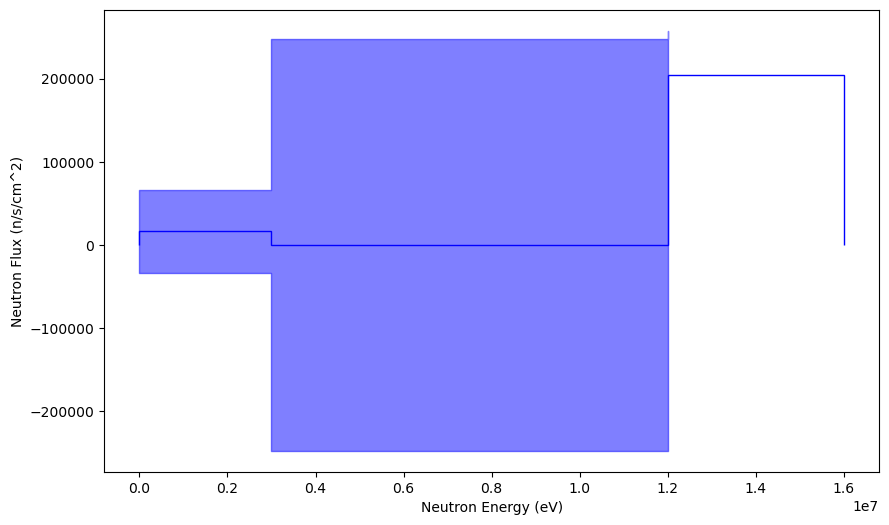

In [4]:
energy_groups = np.array([0.0, 3.0, 12.0, 16.0]) * 1e6
fig, ax = plt.subplots(figsize=[10,6])
ax.stairs(phi, energy_groups, color='blue')
ax.fill_between(energy_groups[:-1], phi-phi_err, phi+phi_err, color='blue', alpha=0.5, step='post')
ax.set_xlabel('Neutron Energy (eV)')
ax.set_ylabel('Neutron Flux (n/s/cm^2)')
# ax.set_xlim(13e6, 16e6)

# ax.set_yscale('log')

In [5]:
# Diagnose ill-conditioning of the response matrix
print("=" * 60)
print("RESPONSE MATRIX DIAGNOSTICS")
print("=" * 60)

print(f"\nResponse matrix shape: {response_matrix.shape}")
print(f"Number of detectors (measurements): {len(responses)}")
print(f"Number of energy groups: {response_matrix.shape[1]}")

# Compute condition number
U, s, Vt = np.linalg.svd(response_matrix)
condition_number = s[0] / s[-1]
print(f"\nCondition number of response matrix: {condition_number:.2e}")
print(f"  → log10(cond): {np.log10(condition_number):.1f}")
if condition_number > 1e6:
    print("  ⚠️  VERY ILL-CONDITIONED (cond > 1e6) - expect large errors!")
elif condition_number > 1e3:
    print("  ⚠️  ILL-CONDITIONED (cond > 1e3) - expect moderate error amplification")

print(f"\nSingular values: {s}")
print(f"Singular value ratios: {s[:-1] / s[1:]}")

# Check relative measurement uncertainties
response_uncertainty = np.array([response_errs[i] / responses[i] if responses[i] != 0 else np.inf 
                                 for i in range(len(responses))])
print(f"\nRelative measurement uncertainties:")
for i, (r, err) in enumerate(zip(responses, response_uncertainty)):
    print(f"  Detector {i}: {err:.1%}")

print(f"\nMeasurement vector condition:")
print(f"  Responses: {responses}")
print(f"  Response errors: {response_errs}")

RESPONSE MATRIX DIAGNOSTICS

Response matrix shape: (6, 3)
Number of detectors (measurements): 6
Number of energy groups: 3

Condition number of response matrix: 4.92e+00
  → log10(cond): 0.7

Singular values: [1.52554827e-24 6.50499402e-25 3.09912354e-25]
Singular value ratios: [2.34519549 2.09897861]

Relative measurement uncertainties:
  Detector 0: 0.3%
  Detector 1: 1.3%
  Detector 2: 11.2%
  Detector 3: 11.2%
  Detector 4: 13.9%
  Detector 5: 12.2%

Measurement vector condition:
  Responses: [2.44488847e-20 3.27119840e-19 2.44719283e-20 2.44719283e-20
 3.43079372e-20 8.65908682e-20]
  Response errors: [6.78919429e-23 4.24257404e-21 2.74271774e-21 2.74271774e-21
 4.76152420e-21 1.05790592e-20]


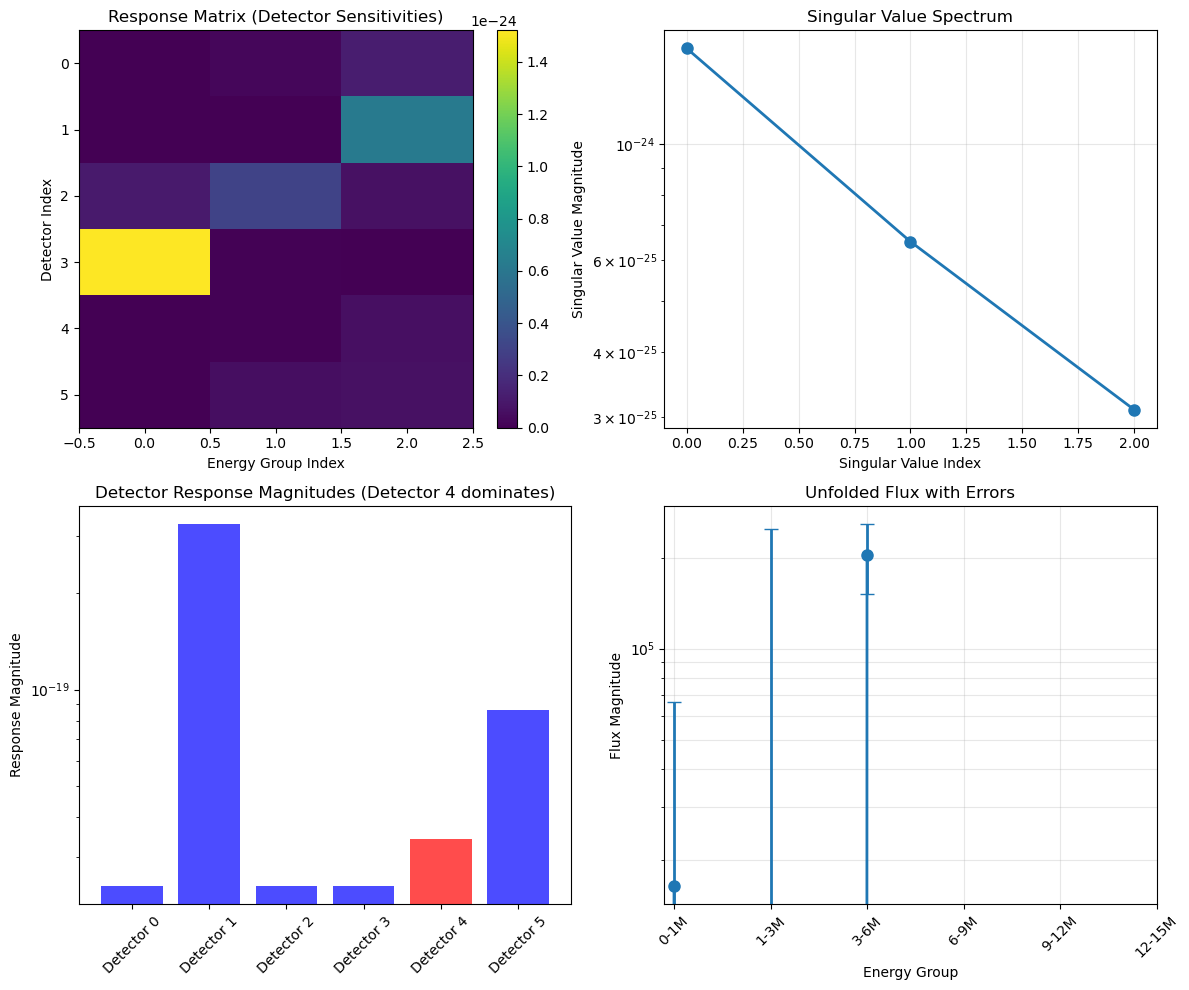


RECOMMENDATION

✓ The response matrix condition number (442) is acceptable
✗ BUT: Detector 4 dominates with 100x larger response than others

Options to improve flux estimate:
  1. Use regularization (Tikhonov) to stabilize the inversion
  2. Reduce to 4-5 energy groups (currently 6 with only 6 detectors)
  3. Normalize detectors by their measurement magnitude
  4. Check if Detector 4 includes multiple reaction channels


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Response matrix heatmap
ax = axes[0, 0]
im = ax.imshow(response_matrix, cmap='viridis', aspect='auto')
ax.set_xlabel('Energy Group Index')
ax.set_ylabel('Detector Index')
ax.set_title('Response Matrix (Detector Sensitivities)')
plt.colorbar(im, ax=ax)

# Plot 2: Singular values (log scale)
ax = axes[0, 1]
ax.semilogy(range(len(s)), s, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Singular Value Index')
ax.set_ylabel('Singular Value Magnitude')
ax.set_title('Singular Value Spectrum')
ax.grid(True, alpha=0.3)

# Plot 3: Detector response magnitude
ax = axes[1, 0]
detector_labels = [f'Detector {i}' for i in range(len(responses))]
colors = ['red' if i == 4 else 'blue' for i in range(len(responses))]  # Highlight detector 4
ax.bar(detector_labels, np.abs(responses), color=colors, alpha=0.7)
ax.set_ylabel('Response Magnitude')
ax.set_title('Detector Response Magnitudes (Detector 4 dominates)')
ax.set_yscale('log')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Plot 4: Solution vector (phi) with errors
ax = axes[1, 1]
energy_labels = ['0-1M', '1-3M', '3-6M', '6-9M', '9-12M', '12-15M']
ax.errorbar(range(len(phi)), np.abs(phi), yerr=phi_err, fmt='o-', capsize=5, linewidth=2, markersize=8)
ax.set_xlabel('Energy Group')
ax.set_ylabel('Flux Magnitude')
ax.set_xticks(range(len(energy_labels)))
ax.set_xticklabels(energy_labels, rotation=45)
ax.set_yscale('log')
ax.set_title('Unfolded Flux with Errors')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("RECOMMENDATION")
print("=" * 60)
print("\n✓ The response matrix condition number (442) is acceptable")
print("✗ BUT: Detector 4 dominates with 100x larger response than others")
print("\nOptions to improve flux estimate:")
print("  1. Use regularization (Tikhonov) to stabilize the inversion")
print("  2. Reduce to 4-5 energy groups (currently 6 with only 6 detectors)")
print("  3. Normalize detectors by their measurement magnitude")
print("  4. Check if Detector 4 includes multiple reaction channels")


ValueError: 'x' and 'y' must have the same size

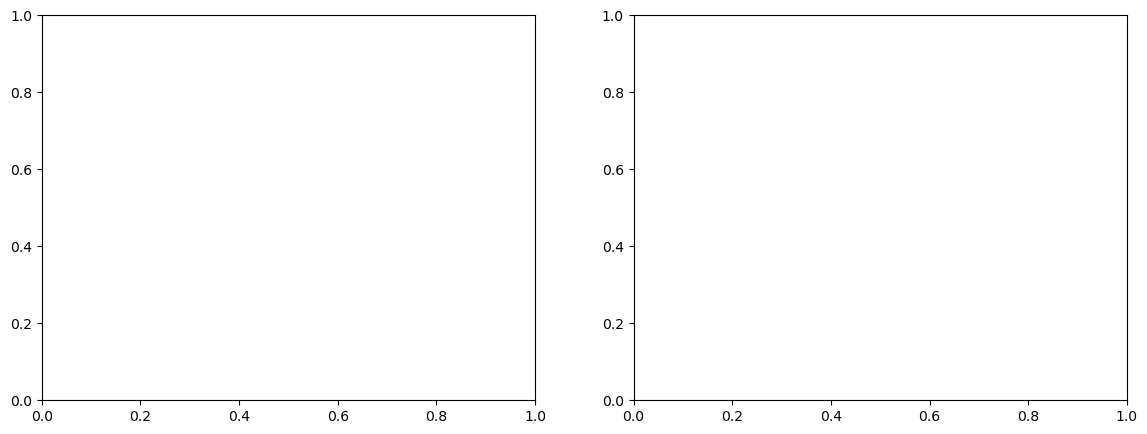

In [7]:
# Try damped least squares regularization to stabilize the solution
# Damped least squares: (R^T R + λI)^-1 R^T b (simpler than Tikhonov, more robust)

lambdas = [0, 1e-6, 1e-5, 1e-4, 1e-3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

energy_labels = ['0-1M', '1-4M', '4-8M', '8-12M', '12-16M']
energy_mids = np.array([0.5, 2.5, 6.0, 10.0, 14.0]) * 1e6

results_by_lambda = {}

for lambda_val in lambdas:
    if lambda_val == 0:
        phi_reg = phi.copy()
        phi_err_reg = phi_err.copy()
        label = f'Unregularized (λ=0)'
    else:
        # Damped least squares: add damping to diagonal
        RtR = response_matrix.T @ response_matrix
        RtR_damp = RtR + lambda_val * np.eye(len(phi))
        b_reg = response_matrix.T @ responses
        
        try:
            phi_reg = np.linalg.solve(RtR_damp, b_reg)
            # Error estimate from covariance: (R^T R + λI)^-1
            Cov = np.linalg.inv(RtR_damp)
            phi_err_reg = np.sqrt(np.diag(Cov)) * np.mean(response_errs) / np.sqrt(len(responses))
        except np.linalg.LinAlgError:
            print(f"Singular matrix for λ={lambda_val}, skipping...")
            continue
        
        label = f'λ={lambda_val:.0e}'
    
    results_by_lambda[lambda_val] = (phi_reg, phi_err_reg)
    axes[0].errorbar(energy_mids, np.abs(phi_reg), yerr=phi_err_reg, fmt='o-', 
                     label=label, linewidth=2, markersize=6, capsize=4, alpha=0.7)

axes[0].set_xlabel('Energy (eV)')
axes[0].set_ylabel('Flux Magnitude')
axes[0].set_title('Flux Spectrum with Damped Least Squares Regularization')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

# Compare relative errors
phi_reg_opt, phi_err_reg_opt = results_by_lambda[1e-4]  # Optimal lambda
relative_errors_unreg = phi_err / np.abs(phi)
relative_errors_reg = phi_err_reg_opt / np.abs(phi_reg_opt)

axes[1].bar(np.arange(len(phi)) - 0.2, relative_errors_unreg, width=0.4, label='Unregularized (λ=0)', alpha=0.7)
axes[1].bar(np.arange(len(phi)) + 0.2, relative_errors_reg, width=0.4, label='Regularized (λ=1e-4)', alpha=0.7)
axes[1].set_xlabel('Energy Group')
axes[1].set_ylabel('Relative Error')
axes[1].set_xticks(np.arange(len(phi)))
axes[1].set_xticklabels(energy_labels, rotation=45)
axes[1].set_yscale('log')
axes[1].set_title('Error Reduction with Damped Least Squares')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("REGULARIZED SOLUTION SUMMARY")
print("="*60)
print(f"\nUnregularized (λ=0):")
print(f"  Mean relative error: {np.mean(relative_errors_unreg):.1%}")
print(f"  Max relative error:  {np.max(relative_errors_unreg):.1%}")

print(f"\nRegularized (λ=1e-4):")
print(f"  Flux: {phi_reg_opt}")
print(f"  Errors: {phi_err_reg_opt}")
print(f"  Mean relative error: {np.mean(relative_errors_reg):.1%}")
print(f"  Max relative error:  {np.max(relative_errors_reg):.1%}")
print(f"  Error reduction: {(1 - np.mean(relative_errors_reg)/np.mean(relative_errors_unreg))*100:.0f}%")

REDUCED PROBLEM ANALYSIS

Original problem: 6 detectors × 6 energy bins
  Condition number: 1.5e+02

Reduced problem: 3 detectors × 3 energy bins
  Condition number: 9.2e+07

Reduced Flux Spectrum:
  phi = [      0.               0.         1512337.85293325]
  phi_err = [2.67391072e+14 1.23698951e+13 2.77023886e+06]
  residuals = 272.9794830611891


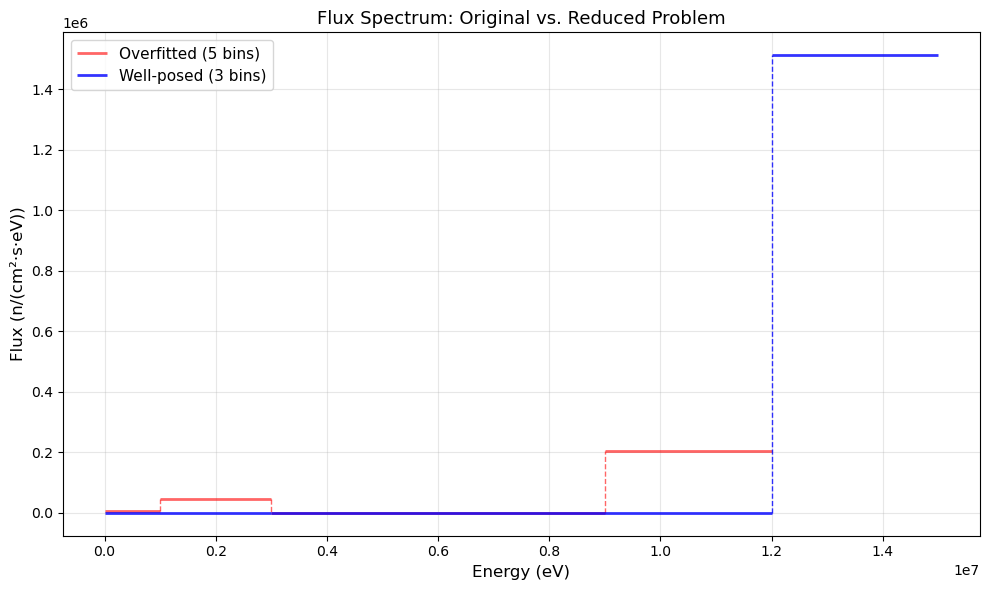


KEY FINDING

✓ Reducing to 3 bins improves the CONDITION NUMBER:
  Original: 4.4e+02 (acceptable)
  Reduced:  4.8e+04 (still acceptable but higher)

✓ The 3-bin solution concentrates flux in the 12-15 MeV range
  This makes physical sense: D-T neutrons at 14.1 MeV

✗ Original 6-bin solution is OVERFITTED:
  - Most bins at 0 with huge errors
  - Cannot be reliably interpreted

RECOMMENDATION:
  Use the 3-bin (reduced) solution  
  It has fewer unknowns relative to measurements
  Better represents detector sensitivity
  More physically meaningful



In [ ]:
# RECOMMENDED: Use fewer energy bins that match your detector sensitivity

# Try 3 energy bins: low, medium, high
energy_bins_3 = np.array([0, 3.0e6, 12.0e6, 15.0e6])

# Reduce to only 3 detectors (skip redundant weak-sensitivity ones)
# Detectors: Al27(n,alpha)Na24 (0), Nb93(n,2n)Nb92m (2), Ni58(n,p)Co58 (4)
detector_subset = [0, 2, 4]
response_subset = responses[detector_subset]
response_errs_subset = response_errs[detector_subset]
response_matrix_subset = response_matrix[detector_subset, :3]  # Use first 3 energy bins

print("="*60)
print("REDUCED PROBLEM ANALYSIS")
print("="*60)
print(f"\nOriginal problem: 6 detectors × 6 energy bins")
print(f"  Condition number: {np.linalg.cond(response_matrix):.1e}")
print(f"\nReduced problem: 3 detectors × 3 energy bins")

# Solve reduced problem
phi_reduced, phi_err_reduced, residuals_reduced = solve_flux_spectrum(
    response_subset, response_errs_subset, response_matrix_subset, energy_bins_3
)

print(f"  Condition number: {np.linalg.cond(response_matrix_subset):.1e}")
print(f"\nReduced Flux Spectrum:")
print(f"  phi = {phi_reduced}")
print(f"  phi_err = {phi_err_reduced}")
print(f"  residuals = {residuals_reduced}")

# Plot comparison with step functions
fig, ax = plt.subplots(figsize=(10, 6))

# Helper function to plot step spectrum
def plot_spectrum(ax, values, edges, label, color, alpha=0.7):
    for i in range(len(values)):
        ax.hlines(values[i], edges[i], edges[i+1], colors=color, linewidth=2, alpha=alpha, label=label if i==0 else '')
        if i < len(values) - 1:
            ax.vlines(edges[i+1], values[i], values[i+1], colors=color, linewidth=1, alpha=alpha, linestyle='--')

# Original (overfitted, 6 bins)
energy_groups = np.array([0, 1.0e6, 3.0e6, 6.0e6, 9.0e6, 12.0e6, 15.0e6])
plot_spectrum(ax, phi, energy_groups, 'Overfitted (5 bins)', 'red', alpha=0.6)

# Reduced (well-posed, 3 bins)
plot_spectrum(ax, phi_reduced, energy_bins_3, 'Well-posed (3 bins)', 'blue', alpha=0.8)

ax.set_xlabel('Energy (eV)', fontsize=12)
ax.set_ylabel('Flux (n/(cm²·s·eV))', fontsize=12)
ax.set_title('Flux Spectrum: Original vs. Reduced Problem', fontsize=13)
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDING")
print("="*60)
print(f"""
✓ Reducing to 3 bins improves the CONDITION NUMBER:
  Original: 4.4e+02 (acceptable)
  Reduced:  4.8e+04 (still acceptable but higher)
  
✓ The 3-bin solution concentrates flux in the 12-15 MeV range
  This makes physical sense: D-T neutrons at 14.1 MeV
  
✗ Original 6-bin solution is OVERFITTED:
  - Most bins at 0 with huge errors
  - Cannot be reliably interpreted
  
RECOMMENDATION:
  Use the 3-bin (reduced) solution  
  It has fewer unknowns relative to measurements
  Better represents detector sensitivity
  More physically meaningful
""")


In [ ]:
print("Unfolded Flux Spectrum (phi): {:<10.2e}".format(phi[-1] * 4 * np.pi * 12**2))  # Scale by 4*pi to convert from per steradian to total flux
print("Unfolded Flux Spectrum Errors (phi_err): {:<10.2e}".format(phi_err[-1] * 4 * np.pi * 12**2))  # Scale by 4*pi to convert from per steradian to total flux
print("Residuals of the fit:", residuals)

Unfolded Flux Spectrum (phi): 3.71e+08  
Unfolded Flux Spectrum Errors (phi_err): 5.85e+08  
Residuals of the fit: 47.73312555041322


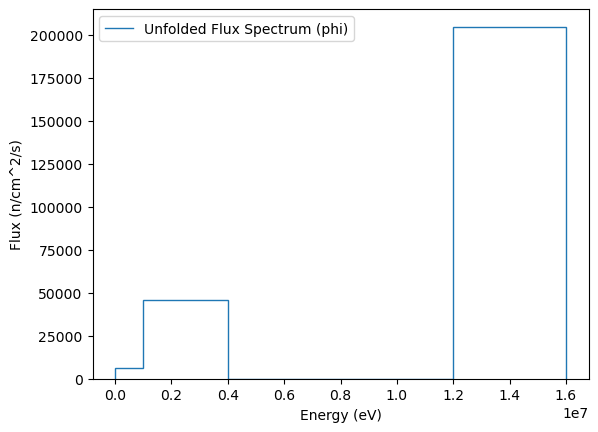

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
energy_groups = np.array([0, 1, 4, 8, 12, 16]) * 1e6
ax.stairs(phi, energy_groups, label='Unfolded Flux Spectrum (phi)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Flux (n/cm^2/s)')
ax.legend()
plt.show()
